# File used for image processing

### Importing packages

In [ ]:
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
from PIL import Image

### Reading images from scraper folders

In [ ]:
#Using the image folder to get the image names:
image_names = listdir("C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Chris\AppData\Local\Temp\ipykernel_24696\629694936.py:1: SyntaxWarning: invalid escape sequence '\C'
  image_names = listdir("C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images")


In [5]:
#Image reader. Reads all images, converts them to RGB values, and stores them in the image_Data list with their dates and image names.
image_Data = []

#Folder to read from:
base_folder = r"C:/Users\Chris\Documents\GitHub\scrandle_ml_project\attempt-18-05-2026\ulle-workspace\grand_scraper_folder\scrandle_data"

#Looping over all folders in the big folder:
for date in sorted(os.listdir(base_folder)):
    
    #Checking if the date chosen actually exists, continueing to next date if not:
    date_path = os.path.join(base_folder, date)
    
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {date}")

    #Reading images and their corresponding date and image name, then placing them into the list
    for i in range(len(image_names)):
        image_path = os.path.join(date_path, image_names[i])
        image_Data.append({
                "date": date,
                "image_name": image_names[i],
                "RGB": plt.imread(image_path, format="webp"),
            })




Processing 2025-04-01
Processing 2025-04-02
Processing 2025-04-03
Processing 2025-04-04
Processing 2025-04-05
Processing 2025-04-06
Processing 2025-04-07
Processing 2025-04-08
Processing 2025-04-09
Processing 2025-04-10
Processing 2025-04-11
Processing 2025-04-12
Processing 2025-04-13
Processing 2025-04-14
Processing 2025-04-15
Processing 2025-04-16
Processing 2025-04-17
Processing 2025-04-18
Processing 2025-04-19
Processing 2025-04-20
Processing 2025-04-21
Processing 2025-04-22
Processing 2025-04-23
Processing 2025-04-24
Processing 2025-04-25
Processing 2025-04-26
Processing 2025-04-27
Processing 2025-04-28
Processing 2025-04-29
Processing 2025-04-30
Processing 2025-05-01
Processing 2025-05-02
Processing 2025-05-03
Processing 2025-05-04
Processing 2025-05-05
Processing 2025-05-06
Processing 2025-05-07
Processing 2025-05-08
Processing 2025-05-09
Processing 2025-05-10
Processing 2025-05-11
Processing 2025-05-12
Processing 2025-05-13
Processing 2025-05-14
Processing 2025-05-15
Processing

In [6]:
#Creating a list with only the images to play around with:
image_only = []
for i in range(len(image_Data)):
    image_only.append(image_Data[i]["RGB"])

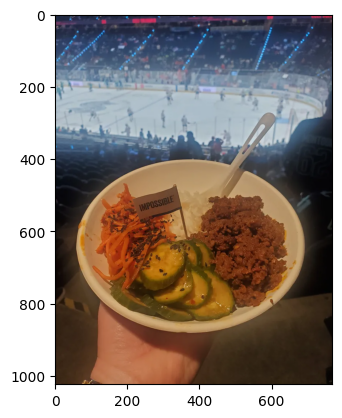

In [13]:
#Showing one of the images as an example:
plt.imshow(image_only[74])

### Padding images to match largest possible scrandle image(feel free to experiment if you want to, though)

In [ ]:

#Reference padding array. see below for explanation
padding_reference = [1024, 1200]

#Getting a reference image from the images folder
images_folder = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"
image_path_example = os.path.join(images_folder, "0_left.webp")
image = Image.open(image_path_example)

#This defines the padding in the given direction.
right = abs(padding_reference[0]-image.size[0])
top = abs(padding_reference[1]-image.size[1])
left = 0
bottom = 0

#Getting the downloaded image´s size, and defining the new width and height
width, height = image.size
new_width = width + right + left
new_height = height + top + bottom

#constructing the resulting image using Image.new:
result = Image.new(image.mode, (new_width, new_height), (0, 0, 0)) #order: image with .mode, the new size, then RGB(currently black)

#Pasting, then saving to the current folder:
result.paste(image, (left, top))
result.save('padded_image.webp')

<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Chris\AppData\Local\Temp\ipykernel_24696\3477247534.py:5: SyntaxWarning: invalid escape sequence '\C'
  images_folder = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"


### Reducing resolution on images

In [18]:
#Code is the same, except now the code also lowers the resolution
 
padding_reference = [1024, 1200]

images_folder = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"
image_path_example = os.path.join(images_folder, "0_left.webp")
image = Image.open(image_path_example)

right = abs(padding_reference[0]-image.size[0])
top = abs(padding_reference[1]-image.size[1])
left = 0
bottom = 0

width, height = image.size
new_width = width + right + left
new_height = height + top + bottom

result = Image.new(image.mode, (new_width, new_height), (0, 0, 0)) #order: image with .mode, the new size, then RGB(currently black)


result.paste(image, (left, top))
#Running thumbnail to lower resolution:
result.thumbnail([100, 100])
result.save('padded_low_res_image.webp')

<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Chris\AppData\Local\Temp\ipykernel_24696\2104228597.py:5: SyntaxWarning: invalid escape sequence '\C'
  images_folder = "C:/Users\Chris\Documents\GitHub\scrandle_ml_project\Chris_workspace\images"


# The Image Processor

The loop that follows processes images for two specific cases: padded images, and low res padded images.
If only the padded images are required, comment out low_res_image.thumbnail([100, 100]), as that is what converts the images to a lower resolution.

In [ ]:
#Creating the folder for our data. Please don´t run unless nescessary.
base_folder = "./scrandle_padded_low_res_data"
os.makedirs(base_folder, exist_ok=True)

In [ ]:
#From the imported list of all photos, i found the following to be the dimensions of the largest possible scrandle picture
#This might, however, change when more scrandles are uploaded to the website, so we should probably check that this is
#Accurate when we get more data in a week or 2.
padding_reference = [1024, 1200]

In [ ]:
#Loop to process images:
#Please don´t run this unless nescessary.

#Getting the folder with the images
base_folder = r"C:/Users\Chris\Documents\GitHub\scrandle_ml_project\attempt-18-05-2026\ulle-workspace\grand_scraper_folder\scrandle_data"
#... and the folder to save to
save_folder = "./scrandle_padded_data"
for date in sorted(os.listdir(base_folder)):

    #Finding a folder with a date that exists:
    date_path = os.path.join(base_folder, date)
    
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {date}")

    #creating a folder for the output if it is not there:
    date_folder = os.path.join(save_folder, date)
    os.makedirs(date_folder, exist_ok=True)

    #Looping over all images in the folder with the original folder to process them:
    for i in range(len(image_names)):
        #Aside from using different folders, this is the same code as the one used to illustrate padding and lowering resolution:
        image_path = os.path.join(date_path, image_names[i])
        im = Image.open(image_path)
        right = abs(padding_reference[0]-im.size[0])
        top = abs(padding_reference[1]-im.size[1])
        left = 0
        bottom = 0
        width, height = im.size

        new_width = width + right + left
        new_height = height + top + bottom

        low_res_image = Image.new(im.mode, (new_width, new_height), (0, 0, 0))

        low_res_image.paste(im, (left, top))
        #low_res_image.thumbnail([100, 100])
        output_image_path = os.path.join(date_folder, image_names[i])
        low_res_image.save(output_image_path)
        
        
        

Processing 2025-04-01
Processing 2025-04-02
Processing 2025-04-03
Processing 2025-04-04
Processing 2025-04-05
Processing 2025-04-06
Processing 2025-04-07
Processing 2025-04-08
Processing 2025-04-09
Processing 2025-04-10
Processing 2025-04-11
Processing 2025-04-12
Processing 2025-04-13
Processing 2025-04-14
Processing 2025-04-15
Processing 2025-04-16
Processing 2025-04-17
Processing 2025-04-18
Processing 2025-04-19
Processing 2025-04-20
Processing 2025-04-21
Processing 2025-04-22
Processing 2025-04-23
Processing 2025-04-24
Processing 2025-04-25
Processing 2025-04-26
Processing 2025-04-27
Processing 2025-04-28
Processing 2025-04-29
Processing 2025-04-30
Processing 2025-05-01
Processing 2025-05-02
Processing 2025-05-03
Processing 2025-05-04
Processing 2025-05-05
Processing 2025-05-06
Processing 2025-05-07
Processing 2025-05-08
Processing 2025-05-09
Processing 2025-05-10
Processing 2025-05-11
Processing 2025-05-12
Processing 2025-05-13
Processing 2025-05-14
Processing 2025-05-15
Processing